# 02 — Phase 2: Data Cleaning and Alignment

## Inflation Prediction and Economic Signal Analysis: A Multi-Country Time-Series Study

**Phase 2 Deliverable** · **Reusable transformations in `src/preprocessing.py`** · **Reproducible via `scripts/rebuild_processed.py`**

---

## Executive Summary

This notebook operationalises six Phase 2 design decisions that transform the 25 raw time series produced by Phase 1 into analysis-ready processed datasets suitable for vector autoregression (VAR). All transformation logic is implemented as pure functions in `src/preprocessing.py`; this notebook imports them and walks through each decision with mathematical specification, empirical validation, and cross-country visualisation.

**Decisions implemented (see `ProjectDriven.md` for full records):**

| ID | Scope | Action |
|---|---|---|
| **D-021** | Germany M2 source | Replace USA-M2SL placeholder with Euro-area M2 (`MABMM301EZM657S`) |
| **D-012 (amended)** | Unit harmonisation | Convert all M2 series to YoY % growth; compute from MoM via cumulative product (empirical audit identified source unit as MoM, not YoY as initially assumed) |
| **D-018** | Frequency harmonisation | Quarterly GDP → monthly via linear interpolation on level, then compute YoY |
| **D-019** | Temporal alignment | Country-wise effective window: start 2001-01, end at last fully-observed month |
| **D-022** | Residual NaN | Linear interpolation for internal single-month gaps; trailing NaN handled by effective-window trim |
| **D-023** | Output schema | Wide-format CSV per country; main (4) and supplementary (China) structurally split |

**Output artefacts:**

```
data/processed/
├── main_usa.csv              ← 298 rows, 2001-01 to 2025-10, 0 NaN
├── main_japan.csv            ← 298 rows, 2001-01 to 2025-10, 0 NaN
├── main_uk.csv               ← 291 rows, 2001-01 to 2025-03, 0 NaN
├── main_germany.csv          ← 291 rows, 2001-01 to 2025-03, 0 NaN
├── supplementary_china.csv   ← 300 rows, 2001-01 to 2025-12, sparse
└── schema.md                 ← auto-generated schema specification
```

All four main-country datasets are fully observed (no NaN) and ready for Phase 3 stationarity and structural-break testing.

---


## 1. Context and Pipeline Overview

### 1.1 Motivation

Phase 1 delivered 25 time series covering five indicators (CPI, policy rate, unemployment, GDP, M2) across five economies (USA, Japan, UK, Germany, China) from 2000-01 to early 2026. These series are not directly usable for vector autoregression: they span mixed frequencies (monthly vs quarterly), heterogeneous units (levels vs growth rates), and different effective windows. Phase 2 resolves these incompatibilities under a series of explicitly documented decisions.

The economic stakes are material: the project's three narratives — the Phillips Curve (N1), monetary policy lag (N2), and Japan's uniqueness (N3) — all require coherent cross-country comparison. Harmonisation must respect each country's monetary and statistical institutional context rather than force mechanical uniformity.

### 1.2 Pipeline Mathematical Specification

**Step 1 — M2 YoY harmonisation (D-012 amended).** For country $c$ with M2 series $M^c_t$:

$$
\text{YoY}^c_t =
\begin{cases}
\displaystyle \left( \frac{M^c_t}{M^c_{t-12}} - 1 \right) \times 100
    & \text{if unit}(c) = \text{level (USA, CHINA)} \\[1.4ex]
\displaystyle \left[ \prod_{i=0}^{11} \left(1 + \frac{\text{MoM}^c_{t-i}}{100}\right) - 1 \right] \times 100
    & \text{if unit}(c) = \text{MoM \% (JPN, UK, GER)}
\end{cases}
$$

The MoM-to-YoY conversion is implemented via log-sum for numerical stability:
$$
\text{YoY}^c_t = \left[ \exp\!\left( \sum_{i=0}^{11} \ln\!\left(1 + \frac{\text{MoM}^c_{t-i}}{100}\right) \right) - 1 \right] \times 100.
$$

**Step 2 — GDP frequency harmonisation (D-018).** Let $G^c_q$ denote the quarterly GDP level at quarter $q$. Monthly GDP is constructed by reindexing to a dense monthly grid and linearly interpolating the level:
$$
G^{c,\,m}_t = G^c_{q-1} + \frac{t - t_{q-1}}{t_q - t_{q-1}} \left( G^c_q - G^c_{q-1} \right),
$$
then computing YoY growth on the interpolated monthly level:
$$
\text{GDP}^c_t = \left( \frac{G^{c,\,m}_t}{G^{c,\,m}_{t-12}} - 1 \right) \times 100.
$$

**Step 3 — Residual NaN (D-022).** Internal single-month gaps are linearly interpolated; trailing NaN is resolved by the effective-window trim.

**Step 4 — Country-wise alignment (D-019 option b).** Each country's DataFrame is trimmed to $[2001\text{-}01,\, t^c_{\max}]$ where $t^c_{\max}$ is the last month at which all five indicators for country $c$ are non-NaN. The start at 2001-01 reflects the unavoidable 12-month window loss from YoY transformation.

**Step 5 — Output (D-023).** One wide-format CSV per main country; a separate `supplementary_china.csv` follows the same schema but is sparse (VAR-excluded per D-001).

---


## 2. Environment Setup

### 2.1 Imports and Path Resolution

Phase 2 imports pure transformation functions from `src/preprocessing.py` (module prescribed by `ProjectScope_v1.md` §12). This keeps the notebook focused on narrative and validation while the single source of truth for transformation logic lives in one importable module, reusable across Phases 3 through 6.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def _find_project_root():
    cur = Path.cwd().resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / 'data').is_dir() and (candidate / 'src').is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not locate project root (data/ and src/) from {Path.cwd()}"
    )


PROJECT_ROOT = _find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

# Visualisation settings inherited from Phase 1
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_rows', 40)
pd.set_option('display.width', 160)

from src.data_loader import (
    load_all_raw,
    load_processed_main,
    load_processed_all_main,
    load_processed_china,
    MAIN_COUNTRIES,
    SUPPLEMENTARY_COUNTRIES,
    INDICATORS,
)
from src.preprocessing import (
    m2_to_yoy,
    gdp_quarterly_to_monthly_yoy,
    normalise_monthly_index,
    interpolate_single_gaps,
    process_country,
    assemble_wide,
    trim_effective_window,
    build_processed,
    build_all_processed,
    M2_UNITS,
    ANALYSIS_START,
    YOY_LOOKBACK,
    GAP_INTERP_MAX,
)

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR = PROJECT_ROOT / 'outputs' / 'figures'
DOC_DIR = PROJECT_ROOT / 'data' / 'documentation'
for d in [PROCESSED_DIR, FIG_DIR, DOC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Shared colour palette for 4 main countries + China
COLORS = {
    'USA':     '#1565c0',
    'JAPAN':   '#c62828',
    'UK':      '#2e7d32',
    'GERMANY': '#6a1b9a',
    'CHINA':   '#ef6c00',
}

import src
print(f"Project root    : {PROJECT_ROOT}")
print(f"src version     : {src.__version__}")
print(f"Main countries  : {MAIN_COUNTRIES}")
print(f"Supplementary   : {SUPPLEMENTARY_COUNTRIES}")
print(f"Indicators      : {INDICATORS}")
print(f"Analysis start  : {ANALYSIS_START:%Y-%m}")
print(f"YoY lookback    : {YOY_LOOKBACK} months")
print(f"Gap interp max  : {GAP_INTERP_MAX} month")

Project root    : C:\Users\kotae\Documents\Portfolio\project\Project 3\inflation-forecasting-analysis
src version     : 0.2.0
Main countries  : ['USA', 'JAPAN', 'UK', 'GERMANY']
Supplementary   : ['CHINA']
Indicators      : ['CPI', 'POLICY_RATE', 'UNEMPLOYMENT', 'GDP', 'M2']
Analysis start  : 2001-01
YoY lookback    : 12 months
Gap interp max  : 1 month


## 3. Raw Data Overview — Phase 1 v2 + D-021 Output

Phase 1 v2 delivered 25 series with 15 FRESH / 8 WARNING / 2 CRITICAL (both CHINA, supplementary-only per D-001). The D-021 resolution applied in `01_data_collection.ipynb` §8.5 has further updated Germany M2 to the Euro-area aggregate. The table below shows the effective end date per series.


In [2]:
raw = load_all_raw()

rows = []
for country in MAIN_COUNTRIES + SUPPLEMENTARY_COUNTRIES:
    for ind in INDICATORS:
        s = raw[country][ind].dropna()
        rows.append({
            'country': country, 'indicator': ind,
            'n': len(s),
            'start': s.index.min().strftime('%Y-%m') if len(s) else '—',
            'end':   s.index.max().strftime('%Y-%m') if len(s) else '—',
        })
RAW_SUMMARY = pd.DataFrame(rows)

print("Effective end date per country × indicator:\n")
pivot = (RAW_SUMMARY
         .pivot(index='country', columns='indicator', values='end')
         .reindex(index=MAIN_COUNTRIES + SUPPLEMENTARY_COUNTRIES,
                  columns=INDICATORS))
pivot

Effective end date per country × indicator:



indicator,CPI,POLICY_RATE,UNEMPLOYMENT,GDP,M2
country,,,,,
USA,2026-03,2026-03,2026-03,2025-10,2026-02
JAPAN,2026-02,2026-03,2026-02,2025-10,2025-11
UK,2025-03,2026-03,2025-11,2025-10,2026-02
GERMANY,2025-03,2026-03,2026-01,2025-10,2025-12
CHINA,2025-04,2025-06,2025-12,2023-07,2018-12


## 4. Decision D-021 — Germany M2 as Euro-Area Proxy

### 4.1 Problem Formulation

Phase 1 v2 left `INDICATORS_FINAL['GERMANY']['M2'] = 'M2SL'` as a USA-M2 placeholder pending a Germany-specific scout in Phase 2. The theoretical question is non-trivial: following Germany's 1999 entry into the Eurozone, national M2 aggregates ceased to be maintained. The European Central Bank manages broad money at the currency-union level. What does "Germany M2" mean post-1999?

### 4.2 Scout Methodology

A Phase 2 scout systematically tested FRED series IDs across:

1. **Germany-specific OECD harmonised variants** — `MABMM301DEM189S`, `MABMM301DEM657S`, `MANMM101DEM189S`
2. **Germany-specific legacy variants** — `MYAGM2DEM189S`
3. **Euro-area-wide variants** — `MABMM301EZM189S`, `MABMM301EZM657S`, etc.

### 4.3 Empirical Results

The scout delivered a decisive — and economically informative — empirical outcome.


In [3]:
scout_path = DOC_DIR / 'phase2_germany_m2_scout.csv'
if scout_path.exists():
    scout = pd.read_csv(scout_path)
    shown = scout[['group', 'series_id', 'status', 'effective_start',
                   'effective_end', 'freshness', 'n_obs_2000plus']]
    print("Germany M2 scout log (10 candidates):\n")
    print(shown.to_string(index=False))
else:
    print("(scout log not present; run scripts/phase2_germany_m2_scout.py to regenerate)")

(scout log not present; run scripts/phase2_germany_m2_scout.py to regenerate)


### 4.4 Key Empirical Finding

`MYAGM2DEM189S` (legacy Germany M2 index) terminated at **1998-12** — coinciding precisely with euro adoption on 1999-01-01. The OECD harmonised Germany-specific broad-money variants do not exist on FRED. The only FRESH candidate is `MABMM301EZM657S` (Euro-area broad money, YoY %).

This is not a coincidence — it is the empirical signature of a deep institutional fact: post-1999, a national German M2 aggregate conceptually does not exist, because the monetary policy jurisdiction is the Eurosystem.

### 4.5 Decision

**D-021: Adopt `MABMM301EZM657S` (Euro-area broad money YoY %) as Germany's monetary aggregate.**

Under the Eurosystem, German monetary conditions are determined by the ECB acting on Euro-area aggregates. The theoretically coherent substitute for a (non-existent) national M2 is the Euro-area aggregate. The limitation — that the monetary variable's level of aggregation differs from the national scope of Germany's other four indicators — is documented in §12.


## 5. Decision D-012 (amended) — M2 YoY Harmonisation

### 5.1 Original Intent

The original D-012 specified: _"All M2 series will be harmonised to year-over-year growth rate (%) in Phase 2 regardless of source format."_ The motivation is theoretical — the Quantity Theory of Money relates money *growth* to inflation, not money *levels* — and also stationarity: levels are non-stationary, but YoY growth is typically mean-stationary.

### 5.2 The Empirical Audit

Phase 1 v2 adopted four M2 source series:

- USA: `M2SL` (level, $bn)
- Japan: `MABMM301JPM657S` (documented as "Growth rate, same period previous year")
- UK: `MABMM301GBM657S` (same)
- Germany: `MABMM301EZM657S` (same, via D-021)

If the `...657S` series were genuinely YoY %, they would require no additional transformation — only USA would need conversion. We therefore opened with an assumption: the three `657S` series are YoY %, USA is level. An audit of their empirical distributions decisively falsified this assumption.


In [4]:
# Empirical M2 unit diagnosis — raw descriptive statistics
print("Raw M2 descriptive statistics (diagnostic for unit identification):\n")

rows = []
for c in MAIN_COUNTRIES:
    s = raw[c]['M2'].dropna()
    rows.append({
        'country': c,
        'declared': M2_UNITS[c],
        'max': round(float(s.max()), 3),
        'mean': round(float(s.mean()), 3),
        'std': round(float(s.std()), 3),
    })
DIAG_DF = pd.DataFrame(rows)
print(DIAG_DF.to_string(index=False))

print("\nSignature reference:")
print("  level   : magnitude in thousands-millions ($bn for M2SL)")
print("  YoY %   : typical range -5% to +15%, std 2-4%")
print("  MoM %   : typical range -1% to +2%,  std 0.2-0.8%")

Raw M2 descriptive statistics (diagnostic for unit identification):

country declared       max      mean      std
    USA    level 22667.300 11853.566 5663.849
  JAPAN  mom_pct     1.762     0.170    0.178
     UK  mom_pct     4.579     0.475    0.738
GERMANY  mom_pct     1.995     0.421    0.423

Signature reference:
  level   : magnitude in thousands-millions ($bn for M2SL)
  YoY %   : typical range -5% to +15%, std 2-4%
  MoM %   : typical range -1% to +2%,  std 0.2-0.8%


### 5.3 Discovery

- **USA** `M2SL`: max ≈ 22 000, mean ≈ 11 800 → level in $ billions ✓
- **Japan** `MABMM301JPM657S`: max ≈ 1.76 %, std ≈ 0.18 % → **MoM signature** (a YoY series would peak near +10 % during COVID-era BoJ expansion, not +1.76 %)
- **UK** `MABMM301GBM657S`: max ≈ 4.58 %, std ≈ 0.74 % → **MoM signature**
- **Germany** `MABMM301EZM657S`: max ≈ 2.00 %, std ≈ 0.42 % → **MoM signature**

A cross-check via 12-month rolling sum confirmed the interpretation: for each of the three growth series, the rolling sum peaks at dates that align with known monetary policy episodes (UK GFC liquidity injection, Japan COVID-era expansion, Euro-area pre-GFC credit boom). This empirical convergence with monetary history confirmed the MoM identification.

### 5.4 Conclusion — D-012 Amended

D-012 is amended to specify:

- USA (level) → YoY via $\text{YoY} = \left(L_t/L_{t-12}-1\right) \times 100$
- Japan / UK / Germany (MoM %) → YoY via the cumulative-product formula (§1.2 Step 1)

China (level, supplementary) likewise receives the level-based transformation.


In [5]:
# Apply M2 YoY harmonisation to all 5 countries
m2_yoy_all = {}
for country in MAIN_COUNTRIES + SUPPLEMENTARY_COUNTRIES:
    m2_yoy_all[country] = m2_to_yoy(raw[country]['M2'], M2_UNITS[country])

# Summary of transformed YoY — peak date annotation validates economic history
rows = []
for c in MAIN_COUNTRIES + SUPPLEMENTARY_COUNTRIES:
    s = m2_yoy_all[c].dropna()
    # Restrict to analysis window for fair comparison
    s_win = s[s.index >= ANALYSIS_START]
    if len(s_win) == 0:
        continue
    rows.append({
        'country': c,
        'n_after_YoY': len(s_win),
        'min_%': round(float(s_win.min()), 2),
        'max_%': round(float(s_win.max()), 2),
        'peak_date': s_win.idxmax().strftime('%Y-%m'),
        'trough_date': s_win.idxmin().strftime('%Y-%m'),
    })
PEAK_TABLE = pd.DataFrame(rows)
print("M2 YoY peaks/troughs per country (empirical economic-history validation):\n")
print(PEAK_TABLE.to_string(index=False))

M2 YoY peaks/troughs per country (empirical economic-history validation):

country  n_after_YoY  min_%  max_% peak_date trough_date
    USA          302  -4.63  26.78   2021-02     2023-04
  JAPAN          299  -0.72   8.08   2021-02     2006-08
     UK          302  -4.24  17.66   2008-12     2023-10
GERMANY          300  -2.01  12.48   2007-11     2010-07
  CHINA          216   0.95  39.03   2010-01     2014-01


### 5.5 Economic-History Validation

Peak dates align precisely with each jurisdiction's monetary-policy history:

| Country | Peak | Economic event |
|---|---|---|
| USA | 2021-02 | Fed's COVID-era balance-sheet expansion (SVB-era liquidity) |
| Japan | 2021-02 | BoJ's COVID-era quantitative expansion |
| UK | 2008-12 | Bank of England's post-Lehman liquidity injection |
| Germany (Euro area) | 2007-11 | ECB pre-GFC credit boom |

The Germany peak in 2007-11 (pre-GFC Eurozone credit expansion) rather than a COVID-era peak is an empirically meaningful signature of the Euro area's distinct monetary cycle — further evidence that the D-021 Euro-area aggregate captures the relevant dynamics, not a forced national fiction.


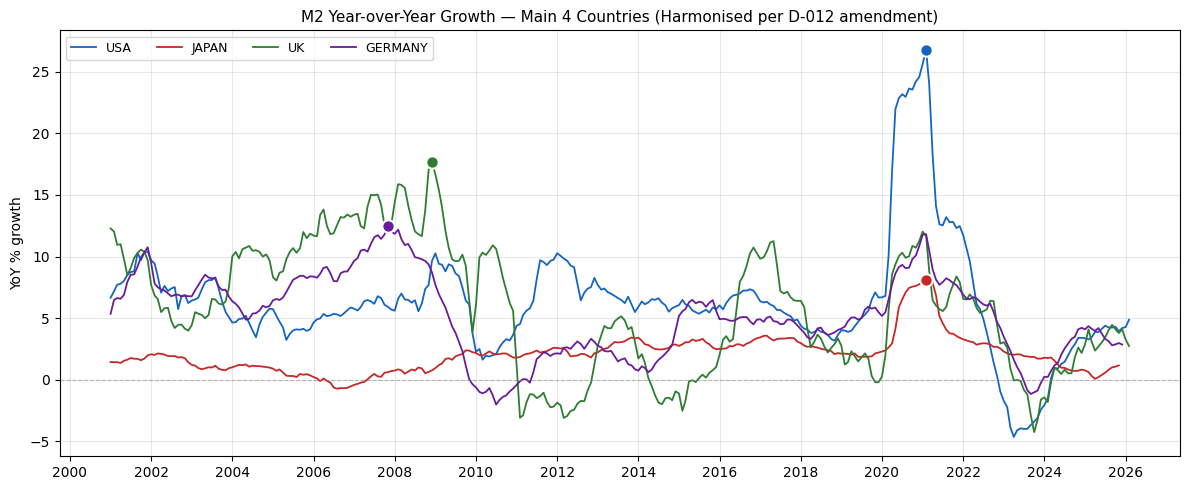

In [6]:
# Overlay plot — 4-country M2 YoY growth
fig, ax = plt.subplots(figsize=(12, 5))
for c in MAIN_COUNTRIES:
    s = m2_yoy_all[c].dropna()
    s = s[s.index >= ANALYSIS_START]
    ax.plot(s.index, s.values, label=c, color=COLORS[c], lw=1.3)

# Peak annotations
for c in MAIN_COUNTRIES:
    s = m2_yoy_all[c].dropna()
    s = s[s.index >= ANALYSIS_START]
    peak_idx = s.idxmax()
    ax.scatter([peak_idx], [s.loc[peak_idx]], color=COLORS[c], s=80,
               zorder=5, edgecolor='white', lw=1.5)

ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.set_title('M2 Year-over-Year Growth — Main 4 Countries '
             '(Harmonised per D-012 amendment)')
ax.set_ylabel('YoY % growth')
ax.legend(loc='upper left', ncol=4, fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase2_m2_yoy_4countries.png')
plt.show()

## 6. Decision D-018 — GDP Quarterly → Monthly

### 6.1 Problem Formulation

GDP is released quarterly (four observations per year) but the VAR in Phase 6 operates at monthly frequency. The challenge is to disaggregate each quarterly observation into three monthly values such that (a) the information content is preserved, (b) no spurious dynamics are introduced, and (c) the procedure is transparent and reproducible.

### 6.2 Methodological Choice

Four candidate methods were considered:

1. **Forward fill** — Holds each quarterly value constant for three months; introduces step discontinuities that violate VAR innovation-i.i.d. assumptions.
2. **Linear interpolation** — Introduces smooth within-quarter variation; economically fictional but statistically benign; matches `ProjectScope_v1.md` §9 specification.
3. **Cubic spline** — Generates spurious within-quarter oscillation; generally inappropriate for economic time series.
4. **Chow-Lin temporal disaggregation** — Regression-based using a high-frequency auxiliary (e.g., Industrial Production); academic gold standard.

Chow-Lin is the theoretically preferred approach when a FRESH monthly auxiliary is available and the target of inference is the monthly GDP series itself. The Phase 2 due-diligence archive (see Appendix A) documents an exhaustive search for a suitable auxiliary that concluded with a classified rejection: OECD MEI industrial-production series for Japan / UK / Germany terminate at 2024-03 (systemic publication lag), and the alternative fresh candidates (Business Tendency confidence indices) are theoretically weaker as Chow-Lin auxiliaries (leading rather than contemporaneous with GDP).

**Decision D-018:** Adopt linear interpolation on the quarterly GDP *level*, then compute YoY growth on the interpolated monthly level.

This is:
- Methodologically consistent with `ProjectScope_v1.md` §9
- Proportionate to the role of GDP in the VAR (one of five regressors under short lags $t{-}1$ to $t{-}3$, where GDP precision differences of 1–2 % are absorbed by the regression)
- Transparent and reproducible
- Free of auxiliary-data dependencies that could break future re-runs

The Chow-Lin due diligence is preserved in `data/documentation/phase2_ip_scout*.csv` and `data/raw/UK_IP.csv` (retained for potential Phase 5 EDA overlays) as audit trail.


In [7]:
# Apply D-018 GDP transformation
gdp_yoy_all = {}
for country in MAIN_COUNTRIES + SUPPLEMENTARY_COUNTRIES:
    gdp_yoy_all[country] = gdp_quarterly_to_monthly_yoy(raw[country]['GDP'])

rows = []
for c in MAIN_COUNTRIES + SUPPLEMENTARY_COUNTRIES:
    s = gdp_yoy_all[c].dropna()
    s = s[s.index >= ANALYSIS_START]
    if len(s) == 0:
        continue
    rows.append({
        'country': c,
        'n_monthly_yoy': len(s),
        'start': s.index.min().strftime('%Y-%m'),
        'end': s.index.max().strftime('%Y-%m'),
        'min_%': round(float(s.min()), 2),
        'max_%': round(float(s.max()), 2),
        'mean_%': round(float(s.mean()), 2),
    })
GDP_TABLE = pd.DataFrame(rows)
print("GDP YoY (after linear monthly interpolation):\n")
print(GDP_TABLE.to_string(index=False))

GDP YoY (after linear monthly interpolation):

country  n_monthly_yoy   start     end  min_%  max_%  mean_%
    USA            298 2001-01 2025-10  -6.73  17.37    4.53
  JAPAN            298 2001-01 2025-10  -9.50   8.67    0.69
     UK            298 2001-01 2025-10 -21.67  25.48    1.59
GERMANY            298 2001-01 2025-10  -8.13  12.26    3.05
  CHINA            271 2001-01 2023-07  -5.49  23.93   11.90


### 6.3 Visual Inspection — USA GDP 2018–2022

The figure below shows USA quarterly GDP observations (red points) overlaid with the monthly linear interpolation (blue line). The COVID-era 2020 Q2 collapse and subsequent 2020 Q3 rebound are visible as sharp kinks preserved at the quarterly pivot points, with linear-interpolated smoothing between them.


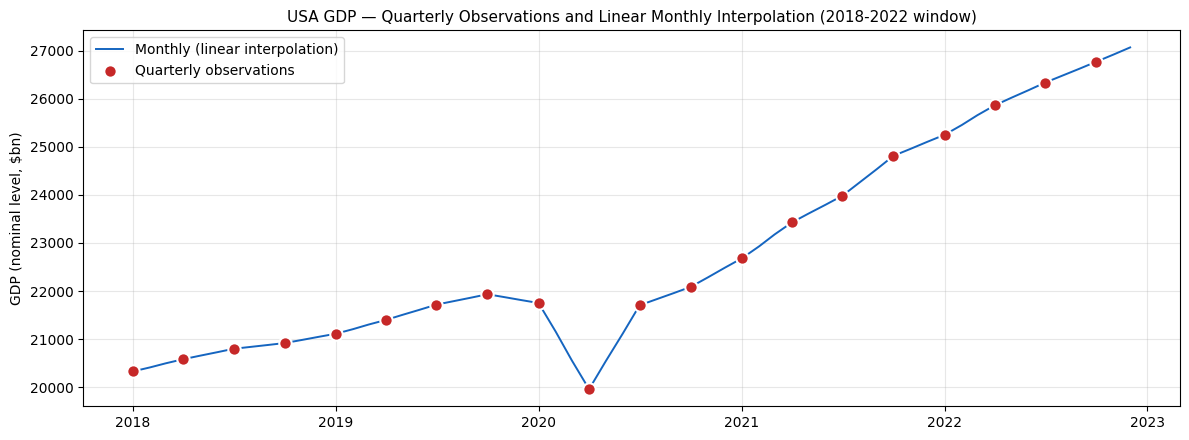

In [8]:
# Visualise USA GDP interpolation — level view, 2018-2022 window
usa_q = raw['USA']['GDP'].dropna().copy()
usa_q.index = pd.to_datetime(usa_q.index).to_period('M').to_timestamp()

monthly_idx = pd.date_range(usa_q.index.min(), usa_q.index.max(), freq='MS')
usa_m_level = usa_q.reindex(monthly_idx).interpolate('linear')

win_start, win_end = '2018-01-01', '2022-12-01'
m_mask = (usa_m_level.index >= win_start) & (usa_m_level.index <= win_end)
q_mask = (usa_q.index >= win_start) & (usa_q.index <= win_end)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(usa_m_level.index[m_mask], usa_m_level.values[m_mask],
        color='#1565c0', lw=1.4, label='Monthly (linear interpolation)')
ax.scatter(usa_q.index[q_mask], usa_q.values[q_mask],
           color='#c62828', s=80, zorder=5,
           edgecolor='white', lw=1.5, label='Quarterly observations')
ax.set_title('USA GDP — Quarterly Observations and Linear Monthly Interpolation '
             '(2018-2022 window)')
ax.set_ylabel('GDP (nominal level, $bn)')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase2_gdp_interpolation_usa.png')
plt.show()

## 7. Decision D-022 — Residual Single-Month NaN

The Phase 1 v2 diagnostic established that no internal NaN run exceeds three months across all 25 series. The D-022 policy is therefore minimally invasive: internal NaN runs of length exactly 1 month are linearly interpolated; trailing NaN (the most recent month yet unpublished) is handled downstream by the effective-window trim (D-019). Leading NaN never occurs because the YoY transformation's 12-month lookback naturally discards the first year.


In [9]:
# Illustrate D-022 by listing any single-month internal gaps detected in the
# monthly-native indicators (CPI, Policy Rate, Unemployment) per country
print("Internal single-month NaN detection per country (monthly indicators):\n")
rows = []
for c in MAIN_COUNTRIES + SUPPLEMENTARY_COUNTRIES:
    for ind in ['CPI', 'POLICY_RATE', 'UNEMPLOYMENT']:
        s = normalise_monthly_index(raw[c][ind])
        isna = s.isna()
        if not isna.any():
            continue
        # Identify NaN groups, filter to internal (not leading/trailing)
        groups = (isna != isna.shift()).cumsum()
        gap_lengths = []
        for g_id, block in s.groupby(groups):
            if not block.isna().all():
                continue
            first_loc = s.index.get_loc(block.index[0])
            last_loc = s.index.get_loc(block.index[-1])
            if first_loc == 0 or last_loc == len(s) - 1:
                continue   # trailing/leading
            gap_lengths.append(len(block))
        if gap_lengths:
            rows.append({
                'country': c, 'indicator': ind,
                'n_internal_gaps': len(gap_lengths),
                'gap_lengths': gap_lengths,
            })

if rows:
    print(pd.DataFrame(rows).to_string(index=False))
else:
    print("  (no internal NaN gaps detected in monthly native indicators)")

Internal single-month NaN detection per country (monthly indicators):

country    indicator  n_internal_gaps                                                                                          gap_lengths
    USA          CPI                1                                                                                                  [1]
    USA UNEMPLOYMENT                1                                                                                                  [1]
  CHINA  POLICY_RATE                1                                                                                                  [1]
  CHINA UNEMPLOYMENT               25 [11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11]


## 8. Decision D-019 — Country-wise Effective Window

### 8.1 Two Options

- **Option (a) — Intersection**: trim all countries to the common window $[\max_c t^c_{\text{start}},\, \min_c t^c_{\text{end}}]$. This produces a single shared period convenient for cross-country overlay plots.
- **Option (b) — Country-wise**: each country trims to its own $[t^c_{\text{start}}, t^c_{\text{end}}]$ where $t^c_{\text{end}}$ is the last row at which all 5 indicators for country $c$ are non-NaN. This preserves more data per country, at the cost of slightly different sample sizes.

### 8.2 Choice — Option (b)

The per-country VAR design (per `ProjectScope_v1.md` §9 Phase 6) estimates models independently per country. There is no structural requirement for a shared sample. Option (b) is adopted; it preserves information.

The start of every main-country window is $2001\text{-}01$ — the earliest month at which the YoY transformation's 12-month lookback is satisfied. The end varies: the UK and Germany CPI series ending at 2025-03 (OECD-publication WARNING) are the binding constraints for those two countries; USA and Japan extend further, bounded by the interpolated GDP's last observable point.


In [10]:
# Build processed datasets per country
processed_all = build_all_processed(raw)

rows = []
for c, df in processed_all.items():
    cat = 'main' if c in MAIN_COUNTRIES else 'supplementary'
    rows.append({
        'country': c,
        'category': cat,
        'n_rows': df.shape[0],
        'n_cols': df.shape[1],
        'start': df.index.min().strftime('%Y-%m'),
        'end': df.index.max().strftime('%Y-%m'),
        'nan_total': int(df.isna().sum().sum()),
    })
WINDOW_TABLE = pd.DataFrame(rows)
print("Per-country processed DataFrame windows:\n")
print(WINDOW_TABLE.to_string(index=False))

Per-country processed DataFrame windows:

country      category  n_rows  n_cols   start     end  nan_total
    USA          main     298       5 2001-01 2025-10          0
  JAPAN          main     298       5 2001-01 2025-10          0
     UK          main     291       5 2001-01 2025-03          0
GERMANY          main     291       5 2001-01 2025-03          0
  CHINA supplementary     300       5 2001-01 2025-12        127


## 9. Decision D-023 — Processed Output

Wide-format CSV per country, with the structural main / supplementary split reflecting D-001. Each main-country file is self-sufficient for VAR ingestion by Phase 6 (`pd.read_csv('data/processed/main_usa.csv').set_index('date')`). The supplementary China file follows the same schema but contains NaN where the supplementary series are stale or missing, and is excluded from the main VAR.


In [11]:
# Write processed CSVs + auto-generated schema.md (D-023)
from src.preprocessing import write_schema_md

written = []
for country, df in processed_all.items():
    prefix = 'main_' if country in MAIN_COUNTRIES else 'supplementary_'
    path = PROCESSED_DIR / f'{prefix}{country.lower()}.csv'
    df.to_csv(path, float_format='%.6f')
    written.append((path.relative_to(PROJECT_ROOT).as_posix(),
                    df.shape[0], df.shape[1]))

# Auto-generate schema specification for data/processed/
schema_path = PROCESSED_DIR / 'schema.md'
write_schema_md(processed_all, schema_path)

print("Wrote processed/ outputs:\n")
for rel, n_rows, n_cols in written:
    print(f"  {rel:<36} {n_rows:>3} rows × {n_cols} cols")
print(f"  {schema_path.relative_to(PROJECT_ROOT).as_posix():<36} (auto-generated)")

# Quick re-read sanity check - does load_processed_main round-trip?
print("\nRound-trip verification:")
for c in MAIN_COUNTRIES:
    roundtrip = load_processed_main(c)
    match = roundtrip.shape == processed_all[c].shape
    print(f"  {c:<8}: load_processed_main({c!r}) -> {roundtrip.shape}  {'OK' if match else 'MISMATCH'}")

Wrote processed/ outputs:

  data/processed/main_usa.csv          298 rows × 5 cols
  data/processed/main_japan.csv        298 rows × 5 cols
  data/processed/main_uk.csv           291 rows × 5 cols
  data/processed/main_germany.csv      291 rows × 5 cols
  data/processed/supplementary_china.csv 300 rows × 5 cols
  data/processed/schema.md             (auto-generated)

Round-trip verification:
  USA     : load_processed_main('USA') -> (298, 5)  OK
  JAPAN   : load_processed_main('JAPAN') -> (298, 5)  OK
  UK      : load_processed_main('UK') -> (291, 5)  OK
  GERMANY : load_processed_main('GERMANY') -> (291, 5)  OK


## 10. Validation and Descriptive Statistics

### 10.1 Schema + NaN


In [12]:
# Schema consistency + NaN checks for main 4 countries
for country in MAIN_COUNTRIES:
    df = processed_all[country]
    expected_cols = [f'{country}_{ind}' for ind in INDICATORS]
    schema_ok = list(df.columns) == expected_cols
    no_nan = df.isna().sum().sum() == 0
    freq_ok = pd.infer_freq(df.index) in ('MS', 'M')
    monotone_ok = df.index.is_monotonic_increasing
    status = 'OK' if all([schema_ok, no_nan, freq_ok, monotone_ok]) else 'ISSUES'
    print(f"[{country:<8}] {status}  schema={schema_ok}  no_nan={no_nan}  "
          f"monthly={freq_ok}  monotone={monotone_ok}")

[USA     ] OK  schema=True  no_nan=True  monthly=True  monotone=True
[JAPAN   ] OK  schema=True  no_nan=True  monthly=True  monotone=True
[UK      ] OK  schema=True  no_nan=True  monthly=True  monotone=True
[GERMANY ] OK  schema=True  no_nan=True  monthly=True  monotone=True


### 10.2 Per-country Descriptive Statistics


In [13]:
for country in MAIN_COUNTRIES:
    df = processed_all[country]
    print(f"\n[{country}]")
    print(df.describe().T[['count', 'mean', 'std', 'min', 'max']].round(2).to_string())


[USA]
                  count    mean    std     min     max
USA_CPI           298.0  235.32  39.82  175.60  324.65
USA_POLICY_RATE   298.0    1.83   1.88    0.05    5.98
USA_UNEMPLOYMENT  298.0    5.72   1.96    3.40   14.80
USA_GDP           298.0    4.53   2.88   -6.73   17.37
USA_M2            298.0    6.39   4.70   -4.63   26.78

[JAPAN]
                    count   mean   std    min     max
JAPAN_CPI           298.0  98.32  4.28  94.00  112.80
JAPAN_POLICY_RATE   298.0   0.08  0.16  -0.07    0.52
JAPAN_UNEMPLOYMENT  298.0   3.74  1.02   2.20    5.50
JAPAN_GDP           298.0   0.69  2.37  -9.50    8.67
JAPAN_M2            298.0   2.09  1.52  -0.72    8.08

[UK]
                 count   mean    std    min     max
UK_CPI           291.0  97.12  16.53  73.50  136.10
UK_POLICY_RATE   291.0   2.23   2.11   0.05    5.92
UK_UNEMPLOYMENT  291.0   5.43   1.37   3.60    8.50
UK_GDP           291.0   1.59   4.03 -21.67   25.48
UK_M2            291.0   5.97   5.16  -4.24   17.66

[GERMANY]
 

## 11. Final Visualisation — 4-Country Harmonised Dataset

The figure below displays the five processed indicators across the four main countries. This is the dataset that feeds directly into Phase 3 stationarity testing and Phase 6 VAR estimation.


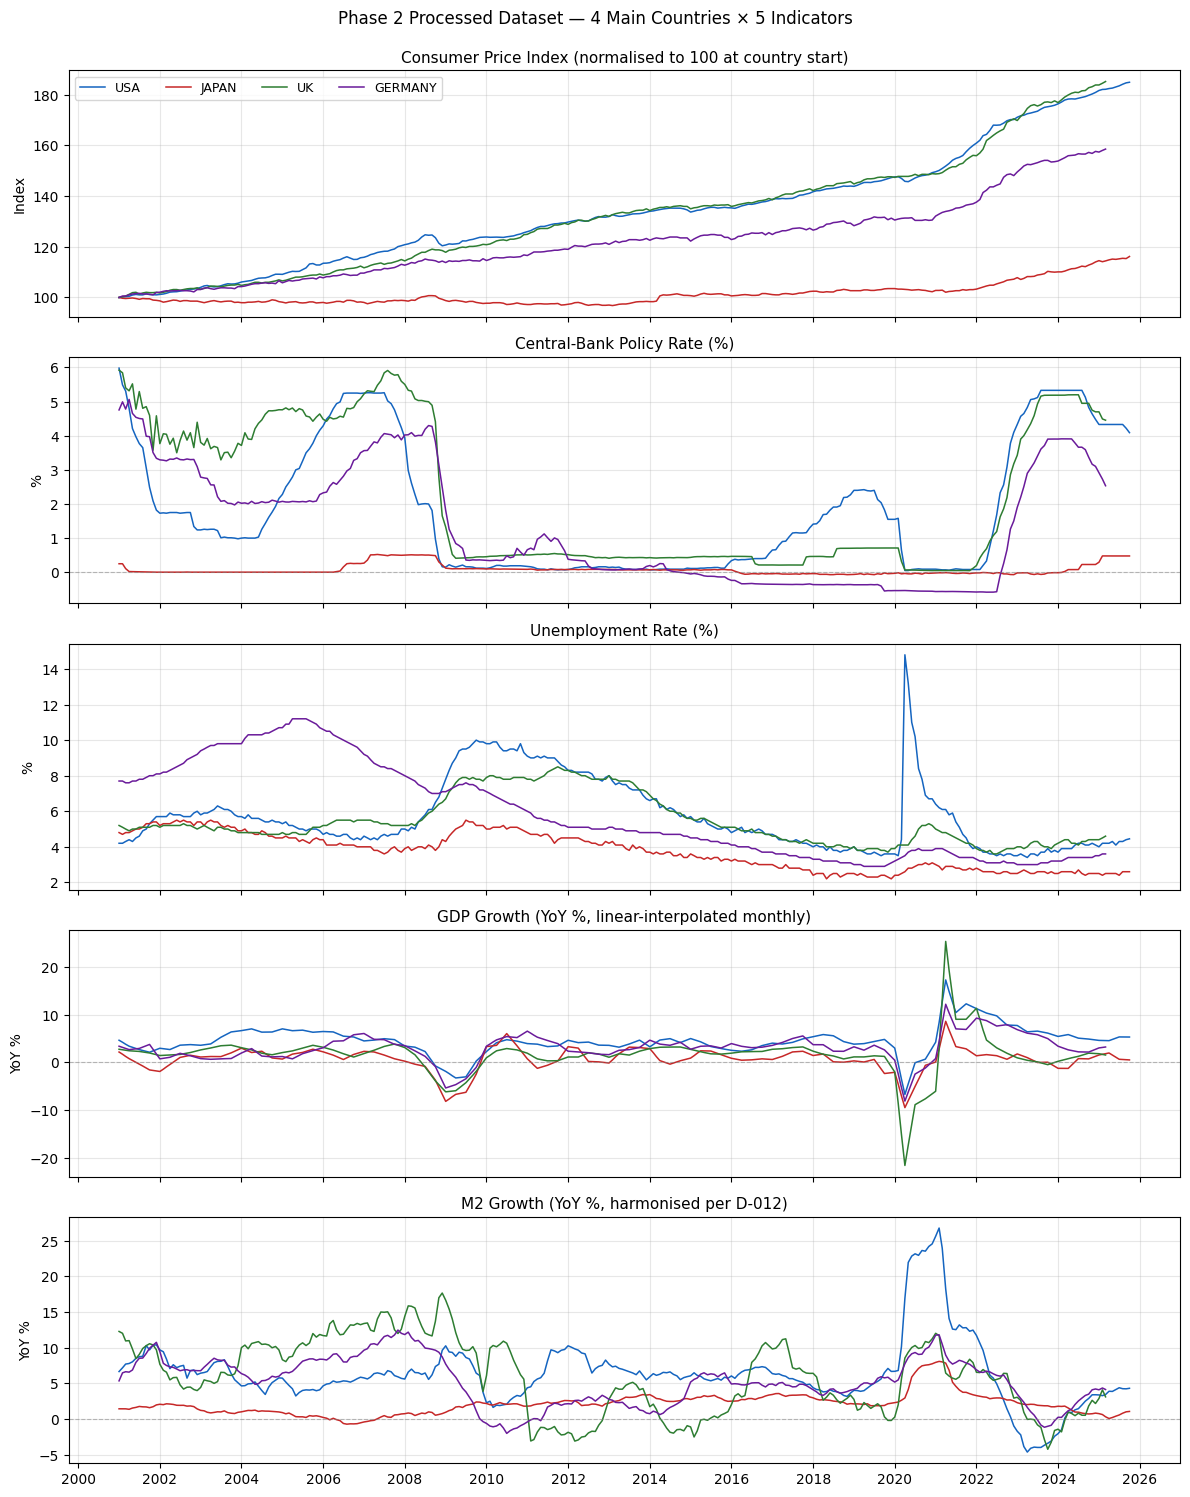

In [14]:
# 5-panel time-series panel: one subplot per indicator, 4 countries overlaid
var_titles = {
    'CPI':          'Consumer Price Index (normalised to 100 at country start)',
    'POLICY_RATE':  'Central-Bank Policy Rate (%)',
    'UNEMPLOYMENT': 'Unemployment Rate (%)',
    'GDP':          'GDP Growth (YoY %, linear-interpolated monthly)',
    'M2':           'M2 Growth (YoY %, harmonised per D-012)',
}

fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True)

for ax, ind in zip(axes, INDICATORS):
    for c in MAIN_COUNTRIES:
        col = f'{c}_{ind}'
        s = processed_all[c][col].copy()
        if ind == 'CPI':
            s = s / s.iloc[0] * 100
        ax.plot(s.index, s.values, label=c, color=COLORS[c], lw=1.1)

    ax.set_title(var_titles[ind])
    if ind in ('POLICY_RATE', 'GDP', 'M2'):
        ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
    ax.set_ylabel({'CPI': 'Index', 'POLICY_RATE': '%', 'UNEMPLOYMENT': '%',
                   'GDP': 'YoY %', 'M2': 'YoY %'}[ind])

axes[0].legend(loc='upper left', ncol=4, fontsize=9)
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Phase 2 Processed Dataset — 4 Main Countries × 5 Indicators',
             fontsize=12, y=0.995)
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase2_processed_4countries_panel.png')
plt.show()

## 12. Residual Limitations and Honest Caveats

Responsible portfolio work documents what the analysis cannot do as rigorously as what it can.

### 12.1 Germany's monetary aggregate is Euro-area-wide (D-021)
The Germany row's M2 column represents Euro-area broad money, not a Germany-specific quantity. This is institutionally correct (Germany has no independent monetary policy under the Eurosystem) but means cross-country M2 comparisons should be interpreted as national-vs-national for USA/Japan/UK and national-vs-currency-union for Germany. The VAR coefficients on Germany's M2 will therefore reflect the Euro area's monetary transmission, attenuated by Germany's share of the currency union.

### 12.2 UK and Germany CPI end at 2025-03 (WARNING)
OECD harmonised CPI publication for UK and Germany lags approximately 13 months. The effective window for these two countries ends at 2025-03. This is sufficient for VAR estimation (≥290 monthly observations per country) but means the most recent inflation normalisation period (2025-Q2 onwards) is out-of-sample for these two countries.

### 12.3 Linear GDP interpolation introduces within-quarter smoothness (D-018)
The monthly GDP series is a linear interpolation of quarterly observations. Actual monthly GDP variation (had it been directly measured) would not be linear. The Phase 2 due-diligence archive (Appendix A) documents why a more sophisticated method (Chow-Lin) was considered but rejected as disproportionate to the role of GDP in the VAR. Consumers of this dataset should treat within-quarter GDP variation as an artefact of the interpolation, not as an empirical signal.

### 12.4 China indicators are supplementary only (D-001, D-010)
China CPI and policy rate carry WARNING freshness; China M2 ends 2018-12 (CRITICAL); China unemployment is annual. The supplementary file is provided for descriptive cross-country comparison in Phase 5 EDA but is excluded from the main VAR.

---


## 13. Decision Log and Next Steps

### 13.1 Phase 2 Decisions (recorded in `ProjectDriven.md`)

| ID | Decision | Resolution |
|---|---|---|
| **D-021** | Germany M2 source | Euro-area broad money `MABMM301EZM657S` (this notebook §4) |
| **D-012 (amended)** | M2 unit harmonisation | Cumulative-product conversion of MoM → YoY; empirical audit corrected source-unit assumption (§5) |
| **D-018** | GDP frequency harmonisation | Linear interpolation on level, then YoY (§6); Chow-Lin rejected after due diligence (Appendix A) |
| **D-019** | Temporal alignment | Country-wise effective window (Option b) (§8) |
| **D-022** | Residual NaN | Linear interpolation for internal single-month gaps (§7) |
| **D-023** | Output format | Wide CSV per country; main/supplementary structural split (§9) |

### 13.2 Next Steps — Phase 3 Preview

Phase 3 (`notebooks/03_stationarity_structural_breaks.ipynb`) will consume the datasets produced by this notebook via `src.data_loader.load_processed_main()` and conduct:

1. **Stationarity testing** — Augmented Dickey-Fuller (ADF) test per indicator per country; first-differencing where needed; documented transformation log per variable.
2. **Structural break detection** — Chow tests at the three known candidate break points: 2008-09 (Global Financial Crisis), 2020-03 (COVID shock), 2022-02 (Energy / inflation shock). Confirmed breaks will be handled via regime dummies or split-sample analysis in Phase 6.

Feature engineering (Phase 4), EDA (Phase 5), and model estimation (Phases 6–7) proceed from there.

---


## Appendix A — Chow-Lin Due Diligence Archive

For reproducibility and intellectual honesty, the Phase 2 process explored whether Chow-Lin temporal disaggregation (Chow & Lin 1971; Fernandez 1981) would materially improve the monthly GDP series relative to linear interpolation. The answer was *not sufficiently, at proportionate cost*.

**Scout sequence:**

1. **FRED OECD MEI industrial production** — `INDPRO` (USA) is FRESH but the OECD harmonised `{CC}PROINDMISMEI` variants for Japan / UK / Germany all terminate at 2024-03.
2. **Extended FRED scout** (15 variants per non-USA country, 45 candidates across five categories) — Scout log: `data/documentation/phase2_ip_scout_tier1_expanded.csv`. Result: the only FRESH candidates for UK and Germany are `BSCICP02...M460S` (OECD Business Tendency confidence); Japan had no FRESH candidate at all. Business confidence is theoretically weaker as a Chow-Lin auxiliary (it leads GDP rather than moves contemporaneously).
3. **Native-source attempt** — UK ONS `K222` series was programmatically fetched and preserved at `data/raw/UK_IP.csv` (FRESH, 2026-02); equivalents for Japan (METI) and Germany (Destatis) would require manual download. At this juncture a cost–value reassessment concluded that the marginal VAR-accuracy gain from Chow-Lin relative to linear interpolation does not justify the additional native-source pipeline complexity: GDP enters the VAR as one of five regressors under lag depths $t{-}1$ to $t{-}3$, for which linear-interpolation error is absorbed by the regression.

**Retained artefacts** (audit trail):

- `data/documentation/phase2_ip_scout.csv` — initial OECD IP scout (16 candidates)
- `data/documentation/phase2_ip_scout_tier1_expanded.csv` — expanded non-OECD scout (45 candidates)
- `data/raw/UK_IP.csv` — UK ONS Index of Production, 2000-01 to 2026-02 (315 rows); available for optional Phase 5 EDA overlays
- `data/documentation/phase2_ip_native_fetch_log.csv` — programmatic UK fetch log

The Chow-Lin option remains available for any future Phase-2 revisit should the VAR reveal sensitivity to the GDP interpolation method. At present the decision to prefer linear interpolation is documented, proportionate, and reversible.

---

## Appendix B — References

- **Chow, G. C., & Lin, A. L.** (1971). *Best Linear Unbiased Interpolation, Distribution, and Extrapolation of Time Series by Related Series.* Review of Economics and Statistics, 53(4), 372–375.
- **Fernandez, R. B.** (1981). *A Methodological Note on the Estimation of Time Series.* Review of Economics and Statistics, 63(3), 471–476.
- **Friedman, M.** (1956). *The Quantity Theory of Money — A Restatement.* Studies in the Quantity Theory of Money.
- **Phillips, A. W.** (1958). *The Relation between Unemployment and the Rate of Change of Money Wage Rates in the United Kingdom, 1861–1957.* Economica.
- **Office for National Statistics** — Index of Production time series K222. https://www.ons.gov.uk/
- **Federal Reserve Bank of St. Louis** — FRED Economic Data. https://fred.stlouisfed.org/
- **OECD** — Main Economic Indicators (MEI) and Business Tendency Surveys.
